<a href="https://colab.research.google.com/github/EdgarJason/PraktikumKAL/blob/main/BAB_4_EDGAR_JASON_HUSIN_245150201111047.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 4. Pemrosesan Awal Data






### 1) Import Data

Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi **wget** untuk mendowload dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh **dataset sebagai latihan awal**. Untuk **tugas** gunakan **dataset yang tertera di modul praktikum (ada perbedaan *dataset*)**.

In [201]:
! wget https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

--2026-04-03 17:29:45--  https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv
Resolving dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)... 52.216.53.210, 16.15.199.60, 52.217.36.232, ...
Connecting to dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)|52.216.53.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv.6’

iris_missing.csv.6  100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-04-03 17:29:46 (103 MB/s) - ‘iris_missing.csv.6’ saved [4593/4593]



Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi [readcsv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) dari library pandas. Lakukan pembacaan berkas csv menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu

In [202]:
import pandas as pd
import numpy as np
data = pd.read_csv('iris_missing.csv')

Tampilkan beberapa baris dari dataset untuk mendapatkan informasi singkat mengenai isi data. Gunakan fungsi **head()** untuk menampilkan 5 data pertama.

In [203]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Berdasarkan informasi dari fungsi **head()**, data iris yang
digunakan mempunyai 4 fitur sebagai berikut :


1.   sepal length
2.   sepal width
3.   petal length
4.   petal width

### 2) Cek Tipe Data dan Statistik Sederhana

Lakukan pengecekan dan pengubahan tipe data apabila tidak sesuai yang diharapkan

In [204]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [205]:
data['sepal_length'] = data['sepal_length'].astype(np.float32)

Coba panggil metode `describe()` dan `info()`. Jelaskan apa perbedaannya sebagai komentar.

In [206]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float32
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float32(1), float64(3), object(1)
memory usage: 5.4+ KB


In [207]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.731334,2.988000,3.684667,1.147333
std,1.153351,0.604893,1.826675,0.773790
min,0.000000,0.000000,0.000000,0.000000
25%,5.100000,2.800000,1.500000,0.225000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


PENJELASAN

Metode info() berfungsi untuk menyajikan ringkasan mengenai struktur teknis dari DataFrame. Informasi yang dihasilkan mencakup jumlah total baris (indeks), jumlah kolom, tipe data pada setiap kolom (Dtype), serta identifikasi jumlah nilai yang tidak kosong (Non-Null Count). Penggunaan metode ini bertujuan untuk memvalidasi integritas struktur data, memastikan kesesuaian tipe data untuk proses komputasi, serta melakukan estimasi awal terhadap beban penggunaan memori (memory usage).

Sementara itu, metode describe() berfokus pada penyajian ringkasan statistik kuantitatif dari isi data tersebut. Secara default, metode ini beroperasi pada kolom-kolom numerik untuk menghasilkan distribusi statistik yang meliputi nilai rata-rata (mean), standar deviasi (std), nilai minimum, nilai maksimum, serta sebaran kuartil (25%, 50%, dan 75%). Fungsi ini digunakan untuk memahami distribusi data, mengidentifikasi rentang nilai, serta melakukan deteksi awal terhadap potensi anomali atau pencilan (outlier) yang dapat memengaruhi akurasi model analisis.

### 3) Missing value dan imputasi data




Jika Anda perhatikan dengan seksama, data pada baris ke-3 (index 2) pada fitur sepal length memiliki nilai 0.0. Hal ini menandakan adanya missing value pada data. Jalankan cell di bawah ini untuk mendapatkan semua data yang mengandung missing value. Pencarian data yang mengandung missing value dilakukan dengan tahapan sebagai berikut:


1.   Membuat filter untuk mencari data dengan sepal_length = 0, sepal_width = 0, petal_length = 0, petal_width =0
2.   Mencari data yang memenuhi kondisi1 **atau** kondisi2 **atau** kondisi3 **atau** kondisi4 menggunakan property [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) pada dataframe



In [208]:
kondisi1 = data['sepal_length']==0.0
kondisi2 = data['sepal_width']==0.0
kondisi3 = data['petal_length']==0.0
kondisi4 = data['petal_width']==0.0
data.loc[kondisi1 | kondisi2 | kondisi3 | kondisi4]

,sepal_length,sepal_width,petal_length,petal_width,Species
2,0.0,3.2,1.3,0.2,Iris-setosa
11,0.0,3.4,1.6,0.2,Iris-setosa
32,5.2,0.0,1.5,0.1,Iris-setosa
47,4.6,3.2,0.0,0.2,Iris-setosa
51,6.4,0.0,4.5,1.5,Iris-versicolor
65,6.7,3.1,4.4,0.0,Iris-versicolor
67,5.8,2.7,0.0,1.0,Iris-versicolor
86,6.7,0.0,4.7,1.5,Iris-versicolor
107,0.0,2.9,6.3,1.8,Iris-virginica
112,6.8,3.0,0.0,2.1,Iris-virginica


Penanganan missing value pada Pandas akan lebih mudah apabila data yang hilang (bernilai 0.0) diganti dengan NaN (Not A Number). Gunakan properti **replace** pada dataframe untuk menggganti 0.0 menjadi NaN

In [209]:
data = data.replace(0.0,np.nan)

Terdapat beberapa cara untuk mengatasi permasalahan missing value pada data. Salah satu cara yang sederhana adalah dengan mengganti nilai NaN pada suatu fitur dengan rata-rata nilai fitur tersebut pada data lain yang bernilai bukan Nan. Perhatikan bahwa Anda harus mengganti nilai NaN dengan rata-rata data lain yang memiliki kategori (species) yang sama.

Fungsi-fungsi pada Pandas yang dapat Anda manfaatkan:


1.   **transform** untuk mengaplikasikan fungsi tertentu pada dataframe, pada permasalahan ini fungsi yang digunakan adalah fungsi **mean**
2.   **groupby** untuk mengelompokkan dataframe berdasarkan nilai kolom tertentu, pada permasalahan ini kolom yang digunakan adalah **species**
3. **fillna** untuk mengganti nilai NaN dengan nilai yang telah ditentukan




Buatlah fungsi bernama **imputasi** yang melakukan tahapan berikut:


1.   Menghitung rata-rata masing-masing kolom berdasarkan kelasnya
2.   Mengisi kolom yang berisi NaN dengan rata-rata kelas yang sesuai




In [210]:
def imputasi(df_input):
  list_columns = df_input.columns
  class_column = list_columns[-1]
  for column in list_columns[:-1]:
    df_input[column] = df_input[column].fillna(
        df_input.groupby(class_column)[column].transform('mean'))

  return df_input

Buatlah sebuah dataframe baru bernama **data_imputasi** yang berisi dataset dengan nilai NaN yang sudah diganti dengan cara memanggil fungsi **imputasi**.

In [211]:
data_imputasi = imputasi(data)

Cek apakah masih terdapat nilai NaN pada dataframe.

In [212]:
data_imputasi.isnull().values.any()

np.False_

In [213]:
data_imputasi.isna().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
Species,False


### 4) Pencarian Outlier
Lakukan plotting terhadap semua fitur pada dataset Iris. Hasil yang diharapkan seperti contoh berikut:
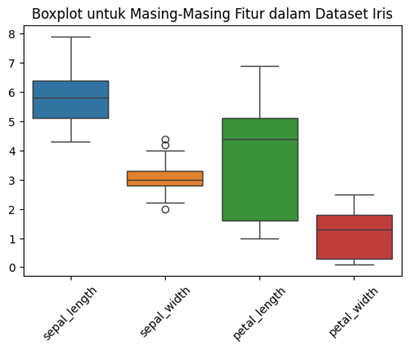

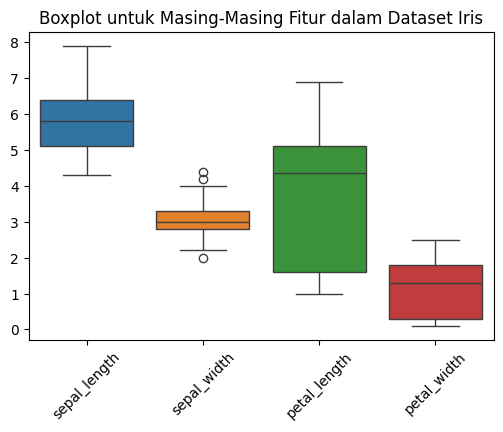

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(data=data_imputasi)
plt.xticks(rotation=45)
plt.title("Boxplot untuk Masing-Masing Fitur dalam Dataset Iris")
plt.show()

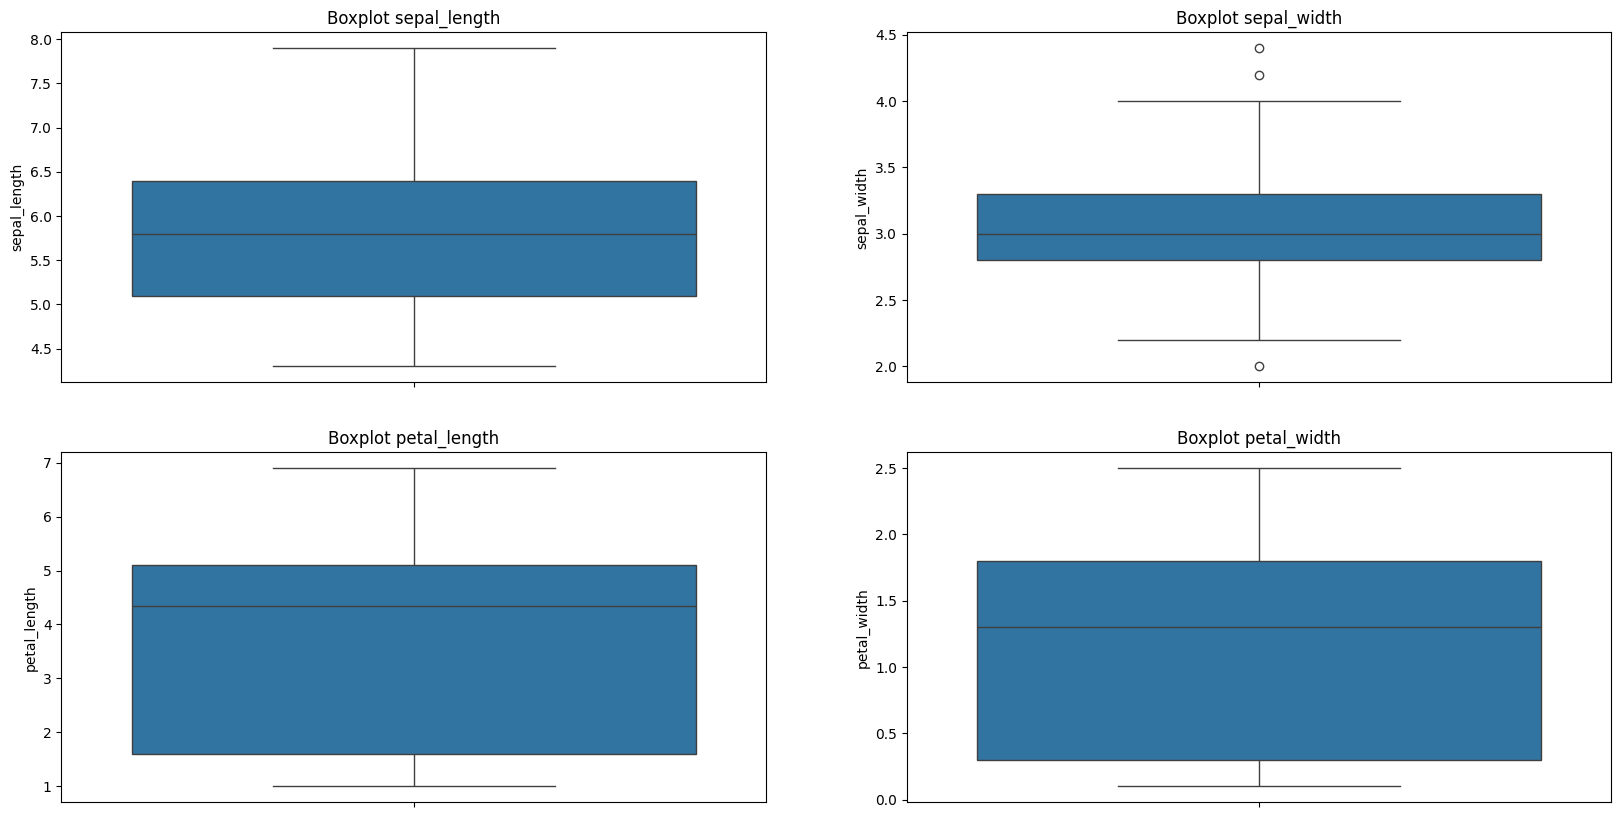

In [215]:
#mengikuti dari video
import matplotlib.pyplot as plt
import seaborn as sns

numeric_feature = data.select_dtypes(include='number').columns

plt.figure(figsize=(20,10))

for i, column in enumerate(numeric_feature, 1):
  plt.subplot(2,2,i)
  sns.boxplot(data[column])
  plt.title(f"Boxplot {column}")

plt.show()

Coba cari *outlier* dengan kode Python

In [216]:
Q1 = data['sepal_width'].quantile(0.25)
Q3 = data['sepal_width'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Batas Bawah: {lower_bound}")
print(f"Batas Atas: {upper_bound}")

Batas Bawah: 2.05
Batas Atas: 4.05


In [217]:
data_without_outliers = data[~((data['sepal_width'] < lower_bound) |
 (data['sepal_width'] > upper_bound))]

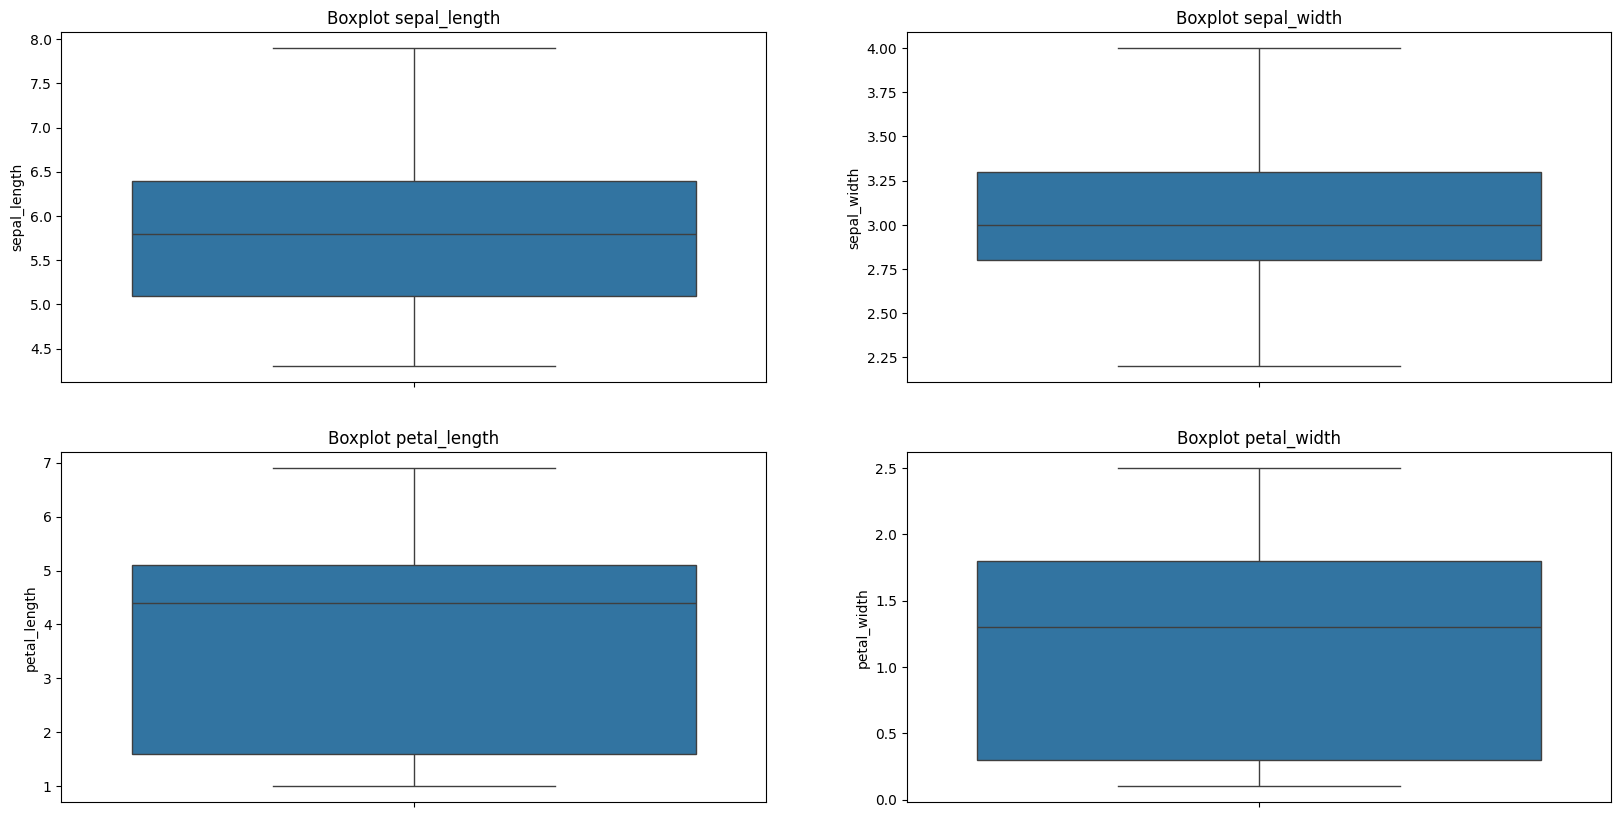

In [218]:
#mengikuti dari video
plt.figure(figsize=(20,10))

for i, column in enumerate(numeric_feature, 1):
  plt.subplot(2,2,i)
  sns.boxplot(data_without_outliers[column])
  plt.title(f"Boxplot {column}")

plt.show()

### 5) Normalisasi MinMax
Normalisasi bertujuan menyamakan rentang nilai pada setiap fitur. Beberapa metode pembelajaran mesin memiliki kinerja yang buruk apabila rentang nilai tiap variabel berbeda jauh.

Sebelum melakukan normalisasi, cek terlebih dahulu rentang (nilai max - nilai min) pada masing masing fitur

In [219]:
def cetak_rentang(df_input):
  list_fitur = df_input.columns[:-1]

  for fitur in list_fitur:
    max = df_input[fitur].max()
    min = df_input[fitur].min()
    print("Rentang fitur ", fitur, " adalah ", max-min)

cetak_rentang(data_imputasi)

Rentang fitur  sepal_length  adalah  3.5999999046325684
Rentang fitur  sepal_width  adalah  2.4000000000000004
Rentang fitur  petal_length  adalah  5.9
Rentang fitur  petal_width  adalah  2.4


Terlihat bahwa masing-masing fitur memiliki rentang yang berbeda, meskipun tidak terlalu signifikan. Pada praktikum ini Anda akan mengimplementasikan normalisasi MinMax untuk menyamakan rentang setiap fitur menjadi satu (1). Persamaan dari fungsi normalisasi MinMax adalah sebagai berikut:

$x'=\frac{x-min(x)}{max(x)-min(x)}$

dimana $x'$ merupakan nilai ternormalisasi, $x$ adalah nilai asal, $min(x)$ merupakan nilai minimum pada suatu fitur, dan $max(x)$ merupakan nilai maksimum pada suatu fitur.

Implementasikan metode normalisasi MinMax pada fungsi bernama **minmax**.


In [220]:
def minmax(df_input):
  list_fitur = df_input.columns[:-1]

  for fitur in list_fitur:
    max = df_input[fitur].max()
    min = df_input[fitur].min()
    df_input[fitur] = (df_input[fitur]-min)/(max-min)

  return df_input

Buatlah sebuah dataframe baru bernama **data_normal** yang berisi hasil dari metode minmax dengan input **data_imputasi**

In [221]:
data_normal = minmax(data_imputasi)

Cek 5 baris pertama **data_normal**

In [222]:
data_normal.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,Iris-setosa
1,0.166667,0.416667,0.067797,0.041667,Iris-setosa
2,0.199074,0.500000,0.050847,0.041667,Iris-setosa
3,0.083333,0.458333,0.084746,0.041667,Iris-setosa
4,0.194444,0.666667,0.067797,0.041667,Iris-setosa


Tampilkan rentang masing-masing fitur menggunakan fungsi **cetak_rentang** yang telah dibuat

In [223]:
cetak_rentang(data_normal)

Rentang fitur  sepal_length  adalah  1.0
Rentang fitur  sepal_width  adalah  1.0
Rentang fitur  petal_length  adalah  1.0
Rentang fitur  petal_width  adalah  1.0


### 6) Label Encoding

Lakukan *label encoding* pada variabel target "Species", sehingga nantinya misalnya Iris setosa menjadi 0, versicolor menjadi 1, virginica menjadi 2

In [224]:
def label_encoding(x):
  if 'setosa' in x:
    return 0
  if 'versicolor' in x:
    return 1
  if'virginica' in x:
    return 2


Tampilkan hasil DataFrame pada 10 data pertama dan terakhir menggunakan `head()` dan `tail()`

In [225]:
data_normal['Species'] = data_normal['Species'].apply(lambda x: label_encoding(x))

display(data_normal.head(10))
display(data_normal.tail(10))

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.199074,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0
5,0.305556,0.791667,0.118644,0.125000,0
6,0.083333,0.583333,0.067797,0.083333,0
7,0.194444,0.583333,0.084746,0.041667,0
8,0.027778,0.375000,0.067797,0.041667,0
9,0.166667,0.458333,0.084746,0.000000,0


,sepal_length,sepal_width,petal_length,petal_width,Species
140,0.666667,0.458333,0.779661,0.958333,2
141,0.722222,0.458333,0.694915,0.916667,2
142,0.416667,0.291667,0.694915,0.750000,2
143,0.694444,0.500000,0.830508,0.916667,2
144,0.666667,0.541667,0.796610,1.000000,2
145,0.666667,0.416667,0.711864,0.799645,2
146,0.555556,0.208333,0.677966,0.750000,2
147,0.611111,0.416667,0.711864,0.791667,2
148,0.527778,0.583333,0.745763,0.916667,2
149,0.444444,0.416667,0.694915,0.708333,2


## TUGAS
1. Implementasikan metode normalisasi Z-score dengan cara membuat fungsi bernama **zscore**.
2. Normalisasikan dataframe **data_imputasi** menggunakan fungsi **zscore**. Simpan hasilnya pada dataframe bernama **data_zscore**.
3. Jelaskan perbedaan hasil normalisasi **MinMax** dan **ZScore**. Petunjuk : cek nilai rentang, rata-rata dan standar deviasi dari **data_zscore**.


In [226]:
import pandas as pd

def zscore(df_input):
    df_numeric = df_input.select_dtypes(include=['number'])

    mean = df_numeric.mean()
    std = df_numeric.std()

    df_zscore = (df_numeric - mean) / std

    if 'Species' in df_input.columns:
        df_zscore['Species'] = df_input['Species']

    return df_zscore

In [227]:
data_zscore = zscore(data_imputasi)

In [228]:
data_zscore.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,-0.907826,1.053430,-1.336763,-1.312509,0
1,-1.152508,-0.110540,-1.336763,-1.312509,0
2,-1.009776,0.355048,-1.393408,-1.312509,0
3,-1.519531,0.122254,-1.280117,-1.312509,0
4,-1.030167,1.286224,-1.336763,-1.312509,0


DATA NORMAL
===

In [229]:
data_normal.min()

,0
sepal_length,0.0
sepal_width,0.0
petal_length,0.0
petal_width,0.0
Species,0.0


In [230]:
data_normal.max()

,0
sepal_length,1.0
sepal_width,1.0
petal_length,1.0
petal_width,1.0
Species,2.0


In [231]:
data_normal.mean()

,0
sepal_length,0.428346
sepal_width,0.436452
petal_length,0.467774
petal_width,0.456894
Species,1.000000


In [232]:
data_normal.std()

,0
sepal_length,0.227052
sepal_width,0.178985
petal_length,0.299213
petal_width,0.316362
Species,0.819232


ZSCORE
===

In [233]:
data_zscore.min()

,0
sepal_length,-1.886553
sepal_width,-2.438481
petal_length,-1.563346
petal_width,-1.444215
Species,0.000000


In [234]:
data_zscore.max()

,0
sepal_length,2.517722
sepal_width,3.148577
petal_length,1.778754
petal_width,1.716724
Species,2.000000


In [235]:
data_zscore.mean()

,0
sepal_length,-2.684765e-07
sepal_width,2.842171e-16
petal_length,9.473903e-17
petal_width,0.000000e+00
Species,1.000000e+00


In [236]:
data_zscore.std()

,0
sepal_length,1.000000
sepal_width,1.000000
petal_length,1.000000
petal_width,1.000000
Species,0.819232


In [237]:
print(data_zscore['Species'].value_counts())

Species
0    50
1    50
2    50
Name: count, dtype: int64


Tuliskan jawaban pertanyaan nomor 3 **di sini**

Perbedaan utama antara normalisasi MinMax dan Z-Score terletak pada skala dan distribusi statistik hasil transformasinya. Pada normalisasi MinMax, data dipaksa masuk ke dalam rentang nilai yang pasti, biasanya antara 0 hingga 1, sehingga nilai terkecil selalu menjadi 0 dan nilai terbesar menjadi 1. Sebaliknya, hasil dari Z-Score tidak memiliki batas rentang yang kaku; nilainya bisa positif maupun negatif, namun sebagian besar akan berada di kisaran -3 hingga 3.

Jika kita meninjau dari sisi statistik, data_zscore akan selalu memiliki nilai rata-rata (mean) tepat 0 dan standar deviasi tepat 1, karena metodenya berfokus pada pemusatan data dan penyetaraan tingkat sebaran. Hal ini berbeda dengan MinMax yang nilai rata-rata dan standar deviasinya tetap bervariasi tergantung pada sebaran data asli. Oleh karena itu, Z-Score jauh lebih tangguh (robust) dalam menangani data yang memiliki nilai ekstrem atau outlier, karena nilai tersebut tidak akan "menekan" sisa data lainnya menjadi sangat rapat seperti yang terjadi pada penskalaan MinMax.

PENJELASAN
===
Kode tersebut menerapkan Z-Score Normalization untuk menyelaraskan skala data pada dataset (terlihat seperti data Iris) dengan mengubah nilai setiap fitur sehingga memiliki rata-rata (mean) sebesar 0 dan standar deviasi sebesar 1. Proses ini dilakukan dengan menghitung selisih setiap data dari rata-ratanya kemudian dibagi dengan standar deviasi kolom tersebut, yang bertujuan untuk menghilangkan bias akibat perbedaan satuan atau rentang nilai antar variabel. Verifikasi pada output menunjukkan hasil mean yang mendekati nol (notasi ilmiah $e^{-16}$) dan standar deviasi tepat 1.0

KESIMPULAN
===

Pemrosesan awal data merupakan tahapan krusial dalam machine learning untuk mengatasi masalah data mentah seperti missing value, pencilan (outlier), rentang data yang tidak sama, serta inkonsistensi format. Melalui teknik imputasi, nilai yang hilang dapat diisi (misalnya dengan rata-rata per kelas) agar data tetap informatif, sementara normalisasi seperti MinMax atau Z-score digunakan untuk menyamakan skala fitur agar tidak ada fitur yang mendominasi perhitungan algoritma. Selain itu, teknik encoding diperlukan untuk mengubah data kategori menjadi numerik agar dapat diproses oleh model.